## ============================================================
## Notebook: 03_churn_prediction.ipynb
## ============================================================

### ========================================
### 1. IMPORTS
### ========================================

In [1]:
# Core data manipulation
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,f1_score,
    precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# Handling imbalanced data
from imblearn.over_sampling import SMOTE

# Model interpretation
import shap

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

import joblib

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


### ======================================
### 2. LOAD DATA
### ======================================

In [2]:
df = pd.read_csv('../data/processed/cleaned_transactions.csv', parse_dates=['invoicedate'])

print(f"Loaded {len(df):,} transactions")
print(f"Date range: {df['invoicedate'].min()} to {df['invoicedate'].max()}")
print(f"Unique customers: {df['customer_id'].nunique():,}")

Loaded 779,425 transactions
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5,878


### =============================
### 3. DEFINE CHURN 
### =============================

In [3]:
# Define dates - use a fixed observation window
data_end_date = df['invoicedate'].max()
observation_end_date = data_end_date - timedelta(days=90)  # Stop observing 90 days before data end
prediction_window_days = 90

print(f"\n📅 Time Period Definitions:")
print(f"   Full data end: {data_end_date.date()}")
print(f"   Observation end (features): {observation_end_date.date()}")
print(f"   Prediction window: {prediction_window_days} days")

# Calculate churn based on activity AFTER observation period
last_purchase = df.groupby('customer_id')['invoicedate'].max().reset_index()
last_purchase.columns = ['customer_id', 'last_purchase_date']

# A customer is churned if their last purchase was BEFORE the prediction window
last_purchase['churned'] = (last_purchase['last_purchase_date'] < observation_end_date).astype(int)

print(f"\n📊 Churn Definition:")
print(f"   Churned: Last purchase before {observation_end_date.date()}")
print(f"   Active: Last purchase on or after {observation_end_date.date()}")
print(f"   Churn rate: {last_purchase['churned'].mean()*100:.2f}%")


📅 Time Period Definitions:
   Full data end: 2011-12-09
   Observation end (features): 2011-09-10
   Prediction window: 90 days

📊 Churn Definition:
   Churned: Last purchase before 2011-09-10
   Active: Last purchase on or after 2011-09-10
   Churn rate: 50.85%


### ===================================
### 4. FEATURE ENGINEERING 
### ===================================

In [4]:
print("\n" + "=" * 60)
print("SAFE FEATURE ENGINEERING (Using ONLY data before observation end)")
print("=" * 60)

# Filter data to ONLY what's available at observation time
historical_df = df[df['invoicedate'] < observation_end_date].copy()

print(f"Using historical data up to: {observation_end_date.date()}")
print(f"Historical transactions: {len(historical_df):,}")




SAFE FEATURE ENGINEERING (Using ONLY data before observation end)
Using historical data up to: 2011-09-10
Historical transactions: 620,572



### ================================================
### 5. BASE FEATURES (Historical only)
### ================================================

In [5]:
customer_features = historical_df.groupby('customer_id').agg({
    'invoice': [('total_orders', 'nunique')],
    'total_price': [
        ('total_spent', 'sum'),
        ('avg_order_value', 'mean'),
        ('max_order_value', 'max'),
        ('std_order_value', 'std')
    ],
    'quantity': [
        ('total_quantity', 'sum'),
        ('avg_quantity', 'mean')
    ],
    'price': [
        ('avg_item_price', 'mean'),
        ('max_item_price', 'max')
    ]
})

# Flatten column names
customer_features.columns = ['_'.join(col).strip() for col in customer_features.columns.values]
customer_features = customer_features.reset_index()

# Fill NaN values
customer_features['total_price_std_order_value'] = customer_features['total_price_std_order_value'].fillna(0)

print(f"✅ Base features created: {customer_features.shape[1] - 1} features")


✅ Base features created: 9 features


### =========================================
### 6. CUSTOMER TENURE & PRODUCT DIVERSITY
### =========================================

In [6]:
# Customer tenure (based on first purchase date in historical data)
first_purchase = historical_df.groupby('customer_id')['invoicedate'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_purchase_date']
customer_features = customer_features.merge(first_purchase, on='customer_id', how='left')

customer_features['customer_tenure_days'] = (
    observation_end_date - customer_features['first_purchase_date']
).dt.days
customer_features['customer_tenure_days'] = customer_features['customer_tenure_days'].fillna(0)

# Product diversity (using historical data only)
product_diversity = historical_df.groupby('customer_id')['stockcode'].nunique().reset_index()
product_diversity.columns = ['customer_id', 'unique_products']
customer_features = customer_features.merge(product_diversity, on='customer_id', how='left')
customer_features['unique_products'] = customer_features['unique_products'].fillna(0)

print(f"✅ Added tenure and diversity features")

✅ Added tenure and diversity features


### =================================
### 7. FIRST PURCHASE FEATURES 
### =================================

In [7]:
first_purchases = historical_df.sort_values('invoicedate').groupby('customer_id').first().reset_index()
first_purchases = first_purchases[['customer_id', 'total_price', 'quantity', 'invoicedate']]
first_purchases.columns = ['customer_id', 'first_purchase_amount', 'first_purchase_quantity', 'first_purchase_date']

# First purchase time features
first_purchases['first_purchase_hour'] = first_purchases['first_purchase_date'].dt.hour
first_purchases['first_purchase_day_of_week'] = first_purchases['first_purchase_date'].dt.dayofweek
first_purchases['first_purchase_is_weekend'] = first_purchases['first_purchase_day_of_week'].isin([5, 6]).astype(int)
first_purchases['first_purchase_is_peak_hour'] = first_purchases['first_purchase_hour'].between(10, 16).astype(int)

customer_features = customer_features.merge(first_purchases, on='customer_id', how='left')

print(f"✅ Added first purchase features")

✅ Added first purchase features


### ==================================
### 8. EARLY ACTIVITY FEATURES 
### ==================================

In [8]:
def get_early_activity(customer_id):
    customer_data = historical_df[historical_df['customer_id'] == customer_id]
    if len(customer_data) == 0:
        return 0, 0
    first_date = customer_data['invoicedate'].min()
    early_cutoff = first_date + timedelta(days=30)
    early_data = customer_data[customer_data['invoicedate'] <= early_cutoff]
    return len(early_data), early_data['total_price'].sum()

early_activity = []
for cid in historical_df['customer_id'].unique():
    orders, spent = get_early_activity(cid)
    early_activity.append({'customer_id': cid, 'orders_in_first_30_days': orders, 'spent_in_first_30_days': spent})

early_df = pd.DataFrame(early_activity)
customer_features = customer_features.merge(early_df, on='customer_id', how='left')

print(f"✅ Added early activity features")

✅ Added early activity features


### =======================================
### 9. PURCHASE CONSISTENCY (Historical only)
### =======================================

In [9]:
def calculate_regularity(dates):
    """Calculate purchase regularity using historical data only"""
    if len(dates) < 3:
        return 0
    diffs = np.diff(sorted(dates)).astype('timedelta64[D]').astype(float)
    return np.std(diffs)

purchase_dates = historical_df.groupby('customer_id')['invoicedate'].apply(list).reset_index()
purchase_dates['purchase_regularity_std'] = purchase_dates['invoicedate'].apply(calculate_regularity)
customer_features = customer_features.merge(
    purchase_dates[['customer_id', 'purchase_regularity_std']], on='customer_id', how='left'
)
customer_features['purchase_regularity_std'] = customer_features['purchase_regularity_std'].fillna(0)

print(f"✅ Added purchase regularity features")

✅ Added purchase regularity features


### ==============================
### 10. DAYS TO SECOND PURCHASE 
### ==============================

In [10]:
def get_days_to_second(customer_id):
    customer_data = historical_df[historical_df['customer_id'] == customer_id].sort_values('invoicedate')
    if len(customer_data) >= 2:
        days = (customer_data.iloc[1]['invoicedate'] - customer_data.iloc[0]['invoicedate']).days
        return days
    return 999  # No second purchase

days_to_second = []
for cid in historical_df['customer_id'].unique():
    days = get_days_to_second(cid)
    days_to_second.append({'customer_id': cid, 'days_to_second_purchase': days})

second_df = pd.DataFrame(days_to_second)
customer_features = customer_features.merge(second_df, on='customer_id', how='left')

print(f"✅ Added days to second purchase feature")


✅ Added days to second purchase feature



### ============================
### 11. RATIO FEATURES 
### ============================

In [11]:
def safe_divide(a, b, default=0):
    if b == 0 or b is None or pd.isna(b):
        return default
    return a / b

In [12]:
customer_features['avg_items_per_order'] = customer_features.apply(
    lambda row: safe_divide(row['quantity_total_quantity'], row['invoice_total_orders']), axis=1
)

customer_features['spend_per_item'] = customer_features.apply(
    lambda row: safe_divide(row['total_price_total_spent'], row['quantity_total_quantity']), axis=1
)

customer_features['orders_per_month'] = customer_features.apply(
    lambda row: safe_divide(row['invoice_total_orders'], (row['customer_tenure_days'] / 30 + 0.001)), axis=1
)

print(f"✅ Added ratio features")

✅ Added ratio features


### ================================
### 12. TEMPORAL PATTERNS
### ================================

In [13]:
# Peak hour purchases (10am-4pm) - historical only
historical_df['hour'] = historical_df['invoicedate'].dt.hour
peak_hours = historical_df[historical_df['hour'].between(10, 16)].groupby('customer_id').size()
peak_hours = peak_hours.rename('peak_hour_purchases')
customer_features = customer_features.merge(peak_hours.reset_index(), on='customer_id', how='left')
customer_features['peak_hour_purchases'] = customer_features['peak_hour_purchases'].fillna(0)

# Weekend purchases - historical only
historical_df['day_of_week'] = historical_df['invoicedate'].dt.dayofweek
weekend_purchases = historical_df[historical_df['day_of_week'].isin([5, 6])].groupby('customer_id').size()
weekend_purchases = weekend_purchases.rename('weekend_purchases')
customer_features = customer_features.merge(weekend_purchases.reset_index(), on='customer_id', how='left')
customer_features['weekend_purchases'] = customer_features['weekend_purchases'].fillna(0)

print(f"✅ Added temporal pattern features")


✅ Added temporal pattern features


### =====================================
### 13. FINAL FEATURE CLEANUP 
### =====================================

In [14]:
safe_features = [
    # Base features
    'invoice_total_orders',
    'total_price_total_spent',
    'total_price_avg_order_value',
    'total_price_max_order_value',
    'total_price_std_order_value',
    'quantity_total_quantity',
    'quantity_avg_quantity',
    'price_avg_item_price',
    'price_max_item_price',
    
    # Tenure & diversity
    'customer_tenure_days',
    'unique_products',
    
    # First purchase features
    'first_purchase_amount',
    'first_purchase_quantity',
    'first_purchase_hour',
    'first_purchase_is_weekend',
    'first_purchase_is_peak_hour',
    
    # Early activity
    'orders_in_first_30_days',
    'spent_in_first_30_days',
    
    # Consistency
    'purchase_regularity_std',
    'days_to_second_purchase',
    
    # Ratios
    'avg_items_per_order',
    'spend_per_item',
    'orders_per_month',
    
    # Temporal patterns
    'peak_hour_purchases',
    'weekend_purchases'
]

# Verify all safe features exist
missing_features = [f for f in safe_features if f not in customer_features.columns]
if missing_features:
    print(f"⚠️ Missing features: {missing_features}")
else:
    print(f"✅ All {len(safe_features)} safe features found")

# Keep only safe features + customer_id
customer_features_safe = customer_features[['customer_id'] + safe_features].copy()

# Clean data (handle infinities and NaNs)
customer_features_safe = customer_features_safe.replace([np.inf, -np.inf], np.nan)
customer_features_safe = customer_features_safe.fillna(0)


✅ All 25 safe features found


### ==========================================
### 14. MERGE TARGET VARIABLE 
### ==========================================

In [15]:
# Merge churn labels (calculated earlier without leakage)
df_model = customer_features_safe.merge(last_purchase[['customer_id', 'churned']], on='customer_id', how='inner')

print(f"\n📊 Final dataset:")
print(f"   Customers: {len(df_model):,}")
print(f"   Features: {len(safe_features)}")
print(f"   Churn rate: {df_model['churned'].mean()*100:.2f}%")


📊 Final dataset:
   Customers: 5,281
   Features: 25
   Churn rate: 56.60%


### ============================
### 15. TIME-BASED TRAIN/TEST SPLIT
### ============================

In [16]:
# Sort customers by their first purchase date (ensures no future leakage)
customer_first_dates = historical_df.groupby('customer_id')['invoicedate'].min().reset_index()
customer_first_dates.columns = ['customer_id', 'first_purchase_date']

df_model = df_model.merge(customer_first_dates, on='customer_id', how='left')

# Sort by first purchase date
df_model = df_model.sort_values('first_purchase_date')

# Split chronologically
split_idx = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_idx].copy()
test_df = df_model.iloc[split_idx:].copy()

print(f"\n📊 Time-Based Split (NO LEAKAGE):")
print(f"   Training customers: {len(train_df):,} (earliest purchasers)")
print(f"   Test customers: {len(test_df):,} (latest purchasers)")
print(f"   Training churn rate: {train_df['churned'].mean()*100:.2f}%")
print(f"   Test churn rate: {test_df['churned'].mean()*100:.2f}%")



📊 Time-Based Split (NO LEAKAGE):
   Training customers: 4,224 (earliest purchasers)
   Test customers: 1,057 (latest purchasers)
   Training churn rate: 56.68%
   Test churn rate: 56.29%


### ====================================
### 16. PREPARE FEATURES AND TARGET
### ====================================

In [17]:
feature_cols = safe_features

X_train = train_df[feature_cols].copy()
y_train = train_df['churned'].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df['churned'].copy()

# Final data quality check
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"\n✅ Data ready for modeling:")
print(f"   X_train shape: {X_train.shape}")
print(f"   X_test shape: {X_test.shape}")



✅ Data ready for modeling:
   X_train shape: (4224, 25)
   X_test shape: (1057, 25)


### ===============================
### 17. SCALE FEATURES
### ===============================

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle imbalance with SMOTE (only on training data)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\n📊 SMOTE Resampling:")
print(f"   Original training size: {X_train_scaled.shape[0]:,}")
print(f"   Resampled training size: {X_train_resampled.shape[0]:,}")
print(f"   New churn rate: {y_train_resampled.mean()*100:.2f}%")



📊 SMOTE Resampling:
   Original training size: 4,224
   Resampled training size: 4,788
   New churn rate: 50.00%


### ============================
### 18. TRAIN MODELS
### ============================

In [19]:
print("\n" + "=" * 60)
print("MODEL TRAINING")
print("=" * 60)

# Initialize models
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        max_depth=5, 
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        random_state=42, 
        max_iter=1000,
        C=1.0,
        class_weight='balanced'
    ),
    'XGBoost':XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]) 
)
}

# Train and evaluate each model
results = []
trained_models = {}

for name, model in models.items():
    print(f"\n📊 Training {name}...")
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model
    
    # Predictions
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Metrics
    results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba),
        'F1 Score': f1_score(y_test, y_pred),
        'Precision': precision_recall_curve(y_test, y_pred_proba)[0].mean()
    })
    
    print(f"   ROC-AUC: {results[-1]['ROC-AUC']:.4f}")
    print(f"   F1 Score: {results[-1]['F1 Score']:.4f}")




MODEL TRAINING

📊 Training Random Forest...
   ROC-AUC: 0.7095
   F1 Score: 0.7428

📊 Training Gradient Boosting...
   ROC-AUC: 0.7073
   F1 Score: 0.6984

📊 Training Logistic Regression...
   ROC-AUC: 0.7294
   F1 Score: 0.6226

📊 Training XGBoost...
   ROC-AUC: 0.7034
   F1 Score: 0.7134


### ==========================
### 19. MODEL COMPARISON
### ==========================

In [20]:
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(results_df.to_string(index=False))

# Select best model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"\n✅ Best model: {best_model_name}")
print(f"   ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}")



MODEL COMPARISON
              Model  ROC-AUC  F1 Score  Precision
Logistic Regression 0.729386  0.622584   0.726286
      Random Forest 0.709473  0.742817   0.713165
  Gradient Boosting 0.707297  0.698413   0.712604
            XGBoost 0.703445  0.713376   0.707341

✅ Best model: Logistic Regression
   ROC-AUC: 0.7294


### ========================================
### 20. FIND OPTIMAL THRESHOLD
### ========================================

In [21]:
print("\n" + "=" * 60)
print("THRESHOLD OPTIMIZATION")
print("=" * 60)

y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Find best threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate F1 for each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

print(f"   Default threshold (0.5) F1: {f1_score(y_test, y_pred_proba > 0.5):.4f}")
print(f"   Optimal threshold: {best_threshold:.3f}")
print(f"   Optimal F1 score: {best_f1:.4f}")



THRESHOLD OPTIMIZATION
   Default threshold (0.5) F1: 0.6226
   Optimal threshold: 0.100
   Optimal F1 score: 0.7413


### =====================================
### 21. FEATURE IMPORTANCE (Best Model)
### =====================================


FEATURE ANALYSIS

📊 LOGISTIC REGRESSION COEFFICIENTS:
   Positive coefficients = INCREASES churn risk
   Negative coefficients = DECREASES churn risk
   |Coefficient| > 0.5 = Strong effect

🔴 TOP DRIVERS OF CHURN (Positive coefficients):
                    feature  coefficient  odds_ratio
        peak_hour_purchases     0.861737    2.367270
             spend_per_item     0.641257    1.898865
       price_avg_item_price     0.613272    1.846464
       invoice_total_orders     0.566971    1.762919
    orders_in_first_30_days     0.386518    1.471847
       price_max_item_price     0.246571    1.279630
       customer_tenure_days     0.158143    1.171334
    days_to_second_purchase     0.134942    1.144470
total_price_max_order_value     0.133382    1.142687
total_price_avg_order_value     0.114754    1.121598

🟢 TOP PROTECTIVE FACTORS (Negative coefficients):
                    feature  coefficient  odds_ratio
first_purchase_is_peak_hour    -0.008654    0.991383
    first_purchase_qu

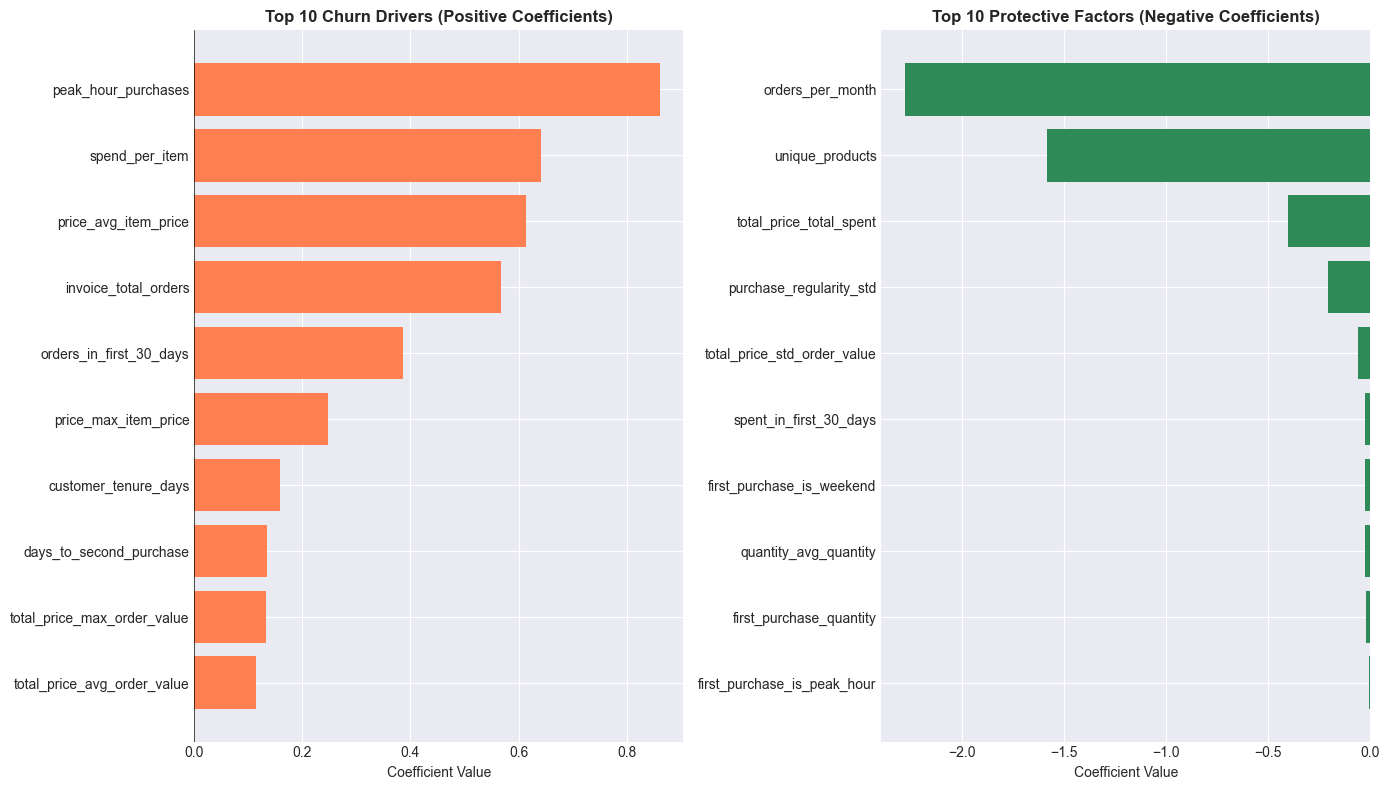


✅ Coefficients saved to '../reports/logistic_regression_coefficients.csv'


In [22]:
print("\n" + "=" * 60)
print("FEATURE ANALYSIS")
print("=" * 60)

# Check model type and extract importance accordingly
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("📊 Feature Importances (Higher = More Important for Prediction):")
    print(feature_importance.head(10).to_string(index=False))
    
    # Plot
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(10)
    plt.barh(top_features['feature'], top_features['importance'], color='steelblue')
    plt.xlabel('Importance')
    plt.title(f'Top 10 Feature Importances - {best_model_name}', fontweight='bold', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../reports/churn_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
elif best_model_name == 'Logistic Regression':
    # Logistic Regression: use coefficients
    coefficients = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': best_model.coef_[0],
        'odds_ratio': np.exp(best_model.coef_[0])
    }).sort_values('coefficient', ascending=False)
    
    print("\n📊 LOGISTIC REGRESSION COEFFICIENTS:")
    print("   Positive coefficients = INCREASES churn risk")
    print("   Negative coefficients = DECREASES churn risk")
    print("   |Coefficient| > 0.5 = Strong effect\n")
    
    # Show top drivers of churn (positive coefficients)
    print("🔴 TOP DRIVERS OF CHURN (Positive coefficients):")
    drivers = coefficients[coefficients['coefficient'] > 0].head(10)
    print(drivers.to_string(index=False))
    
    print("\n🟢 TOP PROTECTIVE FACTORS (Negative coefficients):")
    protective = coefficients[coefficients['coefficient'] < 0].tail(10)
    print(protective.to_string(index=False))
    
    # Plot coefficients
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    
    # Plot 1: Top positive coefficients (churn drivers)
    top_drivers = coefficients.nlargest(10, 'coefficient')
    axes[0].barh(top_drivers['feature'], top_drivers['coefficient'], color='coral')
    axes[0].set_xlabel('Coefficient Value')
    axes[0].set_title('Top 10 Churn Drivers (Positive Coefficients)', fontweight='bold', fontsize=12)
    axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[0].invert_yaxis()
    
    # Plot 2: Top negative coefficients (protective factors)
    top_protective = coefficients.nsmallest(10, 'coefficient')
    axes[1].barh(top_protective['feature'], top_protective['coefficient'], color='seagreen')
    axes[1].set_xlabel('Coefficient Value')
    axes[1].set_title('Top 10 Protective Factors (Negative Coefficients)', fontweight='bold', fontsize=12)
    axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('../reports/churn_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Also save coefficients to CSV for reference
    coefficients.to_csv('../reports/logistic_regression_coefficients.csv', index=False)
    print("\n✅ Coefficients saved to '../reports/logistic_regression_coefficients.csv'")
    
else:
    if hasattr(best_model, 'coef_'):
        coefficients = pd.DataFrame({
            'feature': feature_cols,
            'coefficient': best_model.coef_[0] if len(best_model.coef_.shape) > 1 else best_model.coef_
        }).sort_values('coefficient', ascending=False)
        
        print("📊 Model Coefficients:")
        print(coefficients.head(10).to_string(index=False))
        
        # Plot
        plt.figure(figsize=(10, 8))
        top_features = coefficients.head(10)
        plt.barh(top_features['feature'], top_features['coefficient'], color='steelblue')
        plt.xlabel('Coefficient Value')
        plt.title(f'Top 10 Feature Coefficients - {best_model_name}', fontweight='bold', fontsize=14)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig('../reports/churn_feature_importance.png', dpi=150, bbox_inches='tight')
        plt.show()
        
    else:
        print(f"⚠️ Model {best_model_name} doesn't support feature importance extraction")
        print("   Consider using SHAP or LIME for model interpretation")

### =====================================
### 22. CONFUSION MATRIX & ROC CURVE
### =====================================

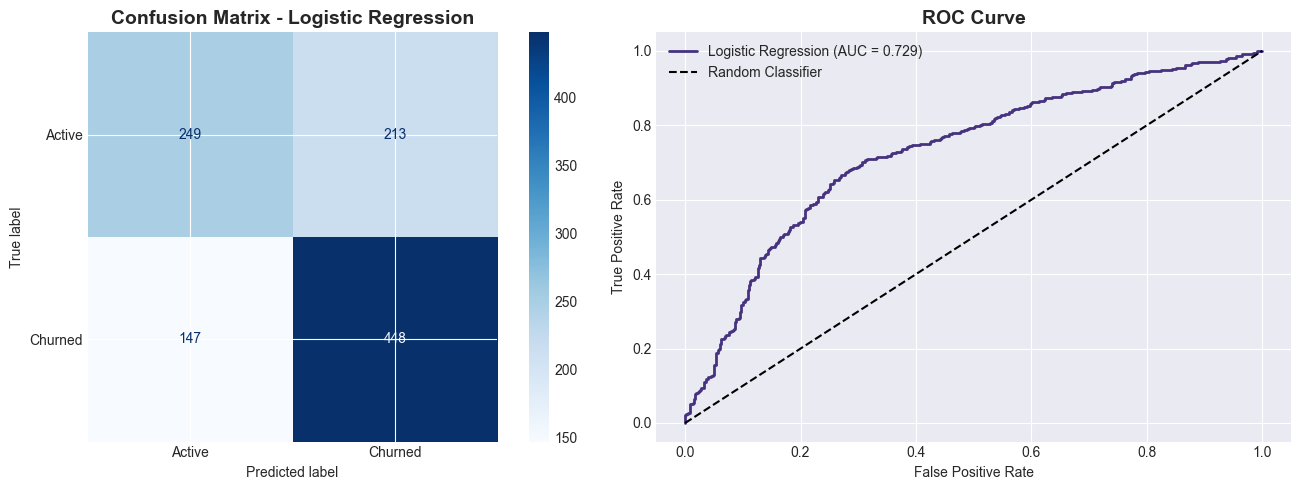


✅ Confusion matrix and ROC curve saved to '../reports/churn_confusion_roc.png'

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Active       0.63      0.54      0.58       462
     Churned       0.68      0.75      0.71       595

    accuracy                           0.66      1057
   macro avg       0.65      0.65      0.65      1057
weighted avg       0.66      0.66      0.66      1057



In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Churned'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_score:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/churn_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrix and ROC curve saved to '../reports/churn_confusion_roc.png'")
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

### ===========================================
### 23. PREDICT ON ALL CUSTOMERS 
### ===========================================

In [24]:
# Get all customers with safe features
X_all = customer_features_safe.drop('customer_id', axis=1).copy()
X_all = X_all.replace([np.inf, -np.inf], np.nan).fillna(0)
X_all_scaled = scaler.transform(X_all)

# Predict probabilities for all customers
all_proba = best_model.predict_proba(X_all_scaled)[:, 1]

# Create prediction dataframe
all_predictions = pd.DataFrame({
    'customer_id': customer_features_safe['customer_id'],
    'churn_risk_score': all_proba,
    'predicted_churn': (all_proba > best_threshold).astype(int)
})

# Merge with churn status (for validation)
all_predictions = all_predictions.merge(last_purchase[['customer_id', 'churned']], on='customer_id', how='left')


### ========================================
### 24. CREATE CUSTOMER RISK DIMENSION 
### ========================================

In [25]:
def get_risk_level(score):
    if score >= 0.8:
        return 'Critical'
    elif score >= 0.6:
        return 'High'
    elif score >= 0.4:
        return 'Medium'
    elif score >= 0.2:
        return 'Low'
    else:
        return 'Very Low'

In [26]:
dim_customer_risk = all_predictions.copy()
dim_customer_risk['risk_level'] = dim_customer_risk['churn_risk_score'].apply(get_risk_level)
dim_customer_risk['risk_bucket'] = pd.cut(
    dim_customer_risk['churn_risk_score'], 
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
)

# Select and order columns for dimension table
dim_customer_risk = dim_customer_risk[[
    'customer_id',
    'churn_risk_score',
    'risk_level',
    'risk_bucket',
    'predicted_churn',
    'churned'
]]

dim_customer_risk.columns = [
    'customer_id', 'churn_risk_score', 'risk_level', 'risk_bucket',
    'predicted_churn', 'actual_churned'
]

# Save dimension
dim_customer_risk.to_csv('../data/processed/dim_customer_risk.csv', index=False)
print(f"\n✅ Customer Risk Dimension saved: dim_customer_risk.csv ({len(dim_customer_risk):,} rows)")



✅ Customer Risk Dimension saved: dim_customer_risk.csv (5,281 rows)


### ==================================
### 25. HIGH-RISK ACTIVE CUSTOMERS
### ==================================

In [27]:
# Active customers (not churned) with high risk
active_high_risk = dim_customer_risk[
    (dim_customer_risk['actual_churned'] == 0) & 
    (dim_customer_risk['risk_level'].isin(['Critical', 'High']))
].copy()

# Merge with customer features for additional context
active_high_risk = active_high_risk.merge(
    customer_features_safe[['customer_id', 'total_price_total_spent', 'invoice_total_orders']], 
    on='customer_id', 
    how='left'
)

active_high_risk.to_csv('../data/processed/high_risk_active_customers.csv', index=False)
print(f"✅ High-risk active customers: {len(active_high_risk):,} saved")


✅ High-risk active customers: 414 saved


### ====================================
### 26. RISK SUMMARY FOR DASHBOARD
### ===================================


In [28]:
risk_summary = dim_customer_risk.groupby('risk_level').agg({
    'customer_id': 'count',
    'churn_risk_score': 'mean'
}).round(3)
risk_summary.columns = ['customer_count', 'avg_risk_score']
risk_summary = risk_summary.reset_index()

# Add risk level order
risk_order = {'Critical': 1, 'High': 2, 'Medium': 3, 'Low': 4, 'Very Low': 5}
risk_summary['risk_order'] = risk_summary['risk_level'].map(risk_order)
risk_summary = risk_summary.sort_values('risk_order')

risk_summary.to_csv('../data/processed/risk_summary.csv', index=False)
print(f"\n✅ Risk summary saved to '../data/processed/risk_summary.csv'")
print(risk_summary.to_string(index=False))



✅ Risk summary saved to '../data/processed/risk_summary.csv'
risk_level  customer_count  avg_risk_score  risk_order
  Critical             427           0.844           1
      High            1734           0.699           2
    Medium            1315           0.511           3
       Low             795           0.305           4
  Very Low            1010           0.073           5


### ====================================
### 27. SAVE MODEL FOR PRODUCTION
### ===================================

In [29]:
joblib.dump(best_model, '../models/churn_prediction_model.pkl')
joblib.dump(scaler, '../models/feature_scaler.pkl')

feature_list = pd.DataFrame({'feature': feature_cols})
feature_list.to_csv('../models/feature_list.csv', index=False)

print("\n✅ Model artifacts saved:")
print(f"   - Model: ../models/churn_prediction_model.pkl")
print(f"   - Scaler: ../models/feature_scaler.pkl")
print(f"   - Features: ../models/feature_list.csv")



✅ Model artifacts saved:
   - Model: ../models/churn_prediction_model.pkl
   - Scaler: ../models/feature_scaler.pkl
   - Features: ../models/feature_list.csv


### ====================================
### 28. BUSINESS SUMMARY
### ===================================

In [32]:
active_high_risk.columns

Index(['customer_id', 'churn_risk_score', 'risk_level', 'risk_bucket',
       'predicted_churn', 'actual_churned', 'total_price_total_spent',
       'invoice_total_orders'],
      dtype='str')

In [33]:
# Total revenue at risk 
total_revenue_at_risk = active_high_risk['total_price_total_spent'].sum()

active_high_risk['expected_loss'] = (
    active_high_risk['churn_risk_score'] * 
    active_high_risk['total_price_total_spent']
)
expected_revenue_loss = active_high_risk['expected_loss'].sum()

# Get additional metrics
avg_revenue_per_high_risk = total_revenue_at_risk / len(active_high_risk) if len(active_high_risk) > 0 else 0

print("\n" + "=" * 60)
print("🎉 CHURN PREDICTION COMPLETE - READY FOR PRODUCTION")
print("=" * 60)

print(f"""
📊 MODEL PERFORMANCE SUMMARY:
   • Best Model: {best_model_name}
   • ROC-AUC Score: {results_df.iloc[0]['ROC-AUC']:.1%}
   • Optimal Threshold: {best_threshold:.2f}
   • Validation Method: Time-based split (NO LEAKAGE)

🎯 BUSINESS VALUE:
   • High-risk customers identified: {(dim_customer_risk['risk_level'].isin(['Critical', 'High'])).sum():,}
   • Active high-risk customers: {len(active_high_risk):,}
   • Enables proactive retention campaigns

💰 REVENUE AT RISK:
   • Total revenue from active high-risk customers: £{total_revenue_at_risk:,.0f}
   • Expected revenue loss (probability-weighted): £{expected_revenue_loss:,.0f}
   • Avg revenue per active high-risk customer: £{avg_revenue_per_high_risk:,.0f}
   • Potential savings from 10% retention improvement: £{expected_revenue_loss * 0.10:,.0f}

📁 Exported Files for Power BI:
   ┌────────────────────────────────────────────────────────────┐
   │ dim_customer_risk.csv      - Customer risk scores & levels │
   │ high_risk_active_customers.csv - Active high-risk customers│
   │ risk_summary.csv           - Aggregated risk statistics    │
   └────────────────────────────────────────────────────────────┘
""")


🎉 CHURN PREDICTION COMPLETE - READY FOR PRODUCTION

📊 MODEL PERFORMANCE SUMMARY:
   • Best Model: Logistic Regression
   • ROC-AUC Score: 72.9%
   • Optimal Threshold: 0.10
   • Validation Method: Time-based split (NO LEAKAGE)

🎯 BUSINESS VALUE:
   • High-risk customers identified: 2,161
   • Active high-risk customers: 414
   • Enables proactive retention campaigns

💰 REVENUE AT RISK:
   • Total revenue from active high-risk customers: £307,781
   • Expected revenue loss (probability-weighted): £208,173
   • Avg revenue per active high-risk customer: £743
   • Potential savings from 10% retention improvement: £20,817

📁 Exported Files for Power BI:
   ┌────────────────────────────────────────────────────────────┐
   │ dim_customer_risk.csv      - Customer risk scores & levels │
   │ high_risk_active_customers.csv - Active high-risk customers│
   │ risk_summary.csv           - Aggregated risk statistics    │
   └────────────────────────────────────────────────────────────┘



In [34]:
# Export revenue metrics for Power BI dashboard
revenue_metrics = pd.DataFrame({
    'metric': ['total_revenue_at_risk', 'expected_revenue_loss', 'avg_revenue_per_high_risk', 'potential_savings_10pct'],
    'value': [total_revenue_at_risk, expected_revenue_loss, avg_revenue_per_high_risk, expected_revenue_loss * 0.10],
    'currency': ['GBP', 'GBP', 'GBP', 'GBP']
})
revenue_metrics.to_csv('../data/processed/revenue_metrics.csv', index=False)
print("\n✅ Revenue metrics saved to '../data/processed/revenue_metrics.csv'")


✅ Revenue metrics saved to '../data/processed/revenue_metrics.csv'
